### Celda 1: dependencias
Esta celda documenta las librerias necesarias. Las instalaciones estan comentadas porque ya se realizaron en `.venv`; solo se descomentan para reconstruir el entorno.

     ---------------------------------------- 0.0/41.7 kB ? eta -:--:--
     --------- ------------------------------ 10.2/41.7 kB ? eta -:--:--
     -------------------------------------- 41.7/41.7 kB 507.4 kB/s eta 0:00:00
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
     ---------------------------------------- 0.0/57.3 kB ? eta -:--:--
     --------------------- ------------------ 30.7/57.3 kB ? eta -:--:--
     --------------------- ------------------ 30.7/57.3 kB ? eta -:--:--
     --------------------- ------------------ 30.7/57.3 kB ? eta -:--:--
     -------------------------------------- 57.3/57.3 kB 273.9 kB/s eta 0:00:00
  Using cached beautifulsoup4-4.15.0-py3-none-any.whl.metadata (3.8 kB)
     ---------------------------------------- 0.0/46.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/46.7 kB ? eta -:--:--
     -------------------------- ------------- 30.7/46.7 kB ? eta -:--:--
     -------------------------- ------------- 30.


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Celda 2: configuracion del entorno
Esta celda selecciona las carpetas del disco `D:` para modelos Ollama y la cache de Hugging Face, e imprime el interprete Python activo.

In [1]:
# Celda 2: configura el entorno y dirige modelos/caches al disco D.
import os
import re
import shutil
import subprocess
import sys
from pathlib import Path
from typing import TypedDict

PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent
OLLAMA_MODELS_DIR = Path(r"d:\Ollama_Modelos")
HF_CACHE_DIR = Path(r"d:\labADA\huggingface_cache")
OLLAMA_MODELS_DIR.mkdir(parents=True, exist_ok=True)
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ["OLLAMA_MODELS"] = str(OLLAMA_MODELS_DIR)
os.environ["HF_HOME"] = str(HF_CACHE_DIR)

print("[Celda 2] Entorno configurado")
print("Python:", sys.version.split()[0])
print("Ejecutable:", sys.executable)
print("OLLAMA_MODELS:", os.environ["OLLAMA_MODELS"])
print("HF_HOME:", os.environ["HF_HOME"])


[Celda 2] Entorno configurado
Python: 3.11.9
Ejecutable: d:\labADA\Presentacion_Jueves\.venv\Scripts\python.exe
OLLAMA_MODELS: d:\Ollama_Modelos
HF_HOME: d:\labADA\huggingface_cache


# Celda 2.5

Creación de una carpeta con los prompts de los agentes

In [2]:
# Celda 2.5: Configuración de carpeta y función para cargar prompts
PROMPTS_DIR = PROJECT_DIR / "prompts"
PROMPTS_DIR.mkdir(parents=True, exist_ok=True) # Crea la carpeta automáticamente si no existe

def cargar_prompt(nombre_archivo: str) -> str:
    """
    Carga el contenido de un archivo .md dentro de la carpeta 'prompts'.
    Si el archivo no existe, lo crea con un texto base para facilitar su edición posterior.
    """
    prompt_path = PROMPTS_DIR / f"{nombre_archivo}.md"
    
    if not prompt_path.exists():
        # Crea un archivo por defecto si es la primera vez que se busca
        texto_base = f"Escribe aquí las instrucciones para {nombre_archivo}..."
        prompt_path.write_text(texto_base, encoding="utf-8")
        print(f"[Prompts] Archivo nuevo creado: {prompt_path.name}")
        return texto_base
        
    return prompt_path.read_text(encoding="utf-8")

print(f"[Prompts] Directorio de prompts configurado en: {PROMPTS_DIR}")

[Prompts] Directorio de prompts configurado en: D:\labADA\Presentacion_Jueves\prompts


### Celda 3: embeddings opcionales
Esta celda deja documentada la dependencia de embeddings. No ejecuta instalaciones para evitar modificar el entorno ya preparado.

In [ ]:
# Opcional: solo instalar si el entorno .venv realmente no tiene embeddings.
# %pip install sentence-transformers

  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-win_amd64.whl.metadata (2.4 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
     ---------------------------------------- 0.0/41.6 kB ? eta -:--:--
     ----------------------------- ---------- 30.7/41.6 kB 1.3 MB/s eta 0:00:01
     ----------------------------- ---------- 30.7/41.6 kB 1.3 MB/s eta 0:00:01
     ----------------------------- ---------- 30.7/41.6 kB 1.3 MB/s eta 0:00:01
     ----------------------------- ---------- 30.7/41.6 kB 1.3 MB/s eta 0:00:01
     ----------------------------- ---------- 30.7/41.6 kB 1.3 MB/s eta 0:00:01
     ----------------------------- ---------- 30.7/41.6 kB 1.3 MB/s eta 0:00:01
     ----------------------------- ---------- 


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Celda 4: ingesta y base RAG
Esta celda convierte `Informe Proyecto Bim 1 EDAII.pdf` a `documento_base.md`. Usa una base separada para no mezclar este documento con `chatlas_hf.db`; si la base nueva ya existe, la abre en solo lectura.

In [3]:
# Celda 4: convierte el documento fuente y prepara la base vectorial RAG.
from markitdown import MarkItDown
from raghilda.chunker import MarkdownChunker
from raghilda.embedding import EmbeddingSentenceTransformers
from raghilda.read import read_as_markdown
from raghilda.store import DuckDBStore

pdf_path = PROJECT_DIR / "data" / "input" / "Informe Proyecto Bim 1 EDAII.pdf"
markdown_path = PROJECT_DIR / "data" / "processed" / "informe_bim1_edaII.md"
db_path = PROJECT_DIR / "data" / "vectorstore" / "informe_bim1_edaII.db"


def convertir_a_markdown(source_path: Path, target_path: Path) -> Path:
    """Convierte el documento original a Markdown una sola vez."""
    if target_path.exists() and target_path.stat().st_size > 0:
        print("[Celda 4] Markdown existente reutilizado")
        return target_path
    if not source_path.exists():
        raise FileNotFoundError(f"No se encontro el documento original: {source_path}")
    resultado = MarkItDown().convert(source_path)
    target_path.write_text(resultado.markdown, encoding="utf-8")
    print("[Celda 4] PDF convertido a Markdown")
    return target_path


def abrir_o_crear_store() -> DuckDBStore:
    """Reutiliza la DB existente; solo crea una nueva si no existe."""
    if db_path.exists():
        print("[Celda 4] Base existente: conexion de solo lectura")
        return DuckDBStore.connect(db_path, read_only=True)
    markdown_file = convertir_a_markdown(pdf_path, markdown_path)
    embedding = EmbeddingSentenceTransformers(model="all-MiniLM-L6-v2")
    writable_store = DuckDBStore.create(db_path, embed=embedding)
    document = read_as_markdown(str(markdown_file))
    chunked_document = MarkdownChunker().chunk(document)
    writable_store.upsert(chunked_document)
    writable_store.build_index()
    del writable_store
    print("[Celda 4] Nueva base creada e indexada")
    return DuckDBStore.connect(db_path, read_only=True)


convertir_a_markdown(pdf_path, markdown_path)
store = abrir_o_crear_store()
print(f"Documento fuente: {pdf_path.name}")
print(f"Markdown: {markdown_path}")
print(f"Base RAG: {db_path} ({store.size()} elementos)")


d:\labADA\Presentacion_Jueves\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Celda 4] Markdown existente reutilizado
[Celda 4] Base existente: conexion de solo lectura


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5720.21it/s]


Documento fuente: Informe Proyecto Bim 1 EDAII.pdf
Markdown: D:\labADA\Presentacion_Jueves\data\processed\informe_bim1_edaII.md
Base RAG: D:\labADA\Presentacion_Jueves\data\vectorstore\informe_bim1_edaII.db (1 elementos)


### Celda 5: estado y herramientas
Esta celda define `QAState`, el extractor TF-IDF y la herramienta que consulta DuckDB y etiqueta cada resultado como fuente `CHUNK`.

In [4]:
# Celda 5: define el estado compartido y las herramientas de los agentes.
from langchain_core.tools import tool
from pydantic import BaseModel, Field
from sklearn.feature_extraction.text import TfidfVectorizer


class QAState(TypedDict, total=False):
    transcripcion_original: str
    conceptos_clave: list[str]
    preguntas_generadas: list[str]
    respuestas_crudas: list[dict[str, str]]
    perfil_objetivo: str
    cuestionario_final: str


def certeza_contexto(contexto: str) -> float:
    """Certeza heuristica basada en cantidad y extension de evidencia recuperada."""
    if contexto == "NO HAY CONTEXTO RECUPERADO.":
        return 0.0
    chunks = contexto.count("--- INICIO CHUNK")
    return round(min(0.95, 0.45 + chunks * 0.15), 2)


@tool
def extraer_conceptos(texto: str, top_n: int = 5) -> list[str]:
    """Extrae los conceptos mas relevantes mediante TF-IDF adaptado al español."""
    sentences = [s.strip() for s in re.split(r"(?<=[.!?])\s+", texto) if s.strip()]
    if len(sentences) < 2:
        sentences.append(texto)
        
    # Lista robusta de stop words en español
    stop_words_es = [
        "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las",
        "por", "un", "para", "con", "no", "una", "su", "al", "lo", "como",
        "más", "pero", "sus", "le", "ya", "o", "este", "sí", "porque", "esta",
        "entre", "cuando", "muy", "sin", "sobre", "también", "me", "hasta",
        "hay", "donde", "quien", "desde", "todo", "nos", "durante", "todos",
        "uno", "les", "ni", "contra", "otros", "ese", "eso", "ante", "ellos",
        "e", "esto", "mí", "antes", "algunos", "qué", "unos", "yo", "otro",
        "otras", "otra", "él", "tanto", "esa", "estos", "mucho", "quienes",
        "nada", "muchos", "cual", "poco", "ella", "estar", "estas", "algunas",
        "algo", "nosotros", "mi", "mis", "tú", "te", "ti", "tu", "tus", "ellas",
        "nosotras", "vosotros", "vosotras", "os", "mío", "mía", "míos", "mías",
        "tuyo", "tuya", "tuyos", "tuyas", "suyo", "suya", "suyos", "suyas",
        "nuestro", "nuestra", "nuestros", "nuestras", "vuestro", "vuestra",
        "vuestros", "vuestras", "es", "son", "fue", "ha", "han", "ser", "sido"
    ]
    
    vectorizer = TfidfVectorizer(stop_words=stop_words_es)
    matrix = vectorizer.fit_transform(sentences)
    scores = matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    
    ranked = sorted(zip(terms, scores), key=lambda pair: pair[1], reverse=True)
    return [term for term, _ in ranked[:top_n]]

@tool
def recuperar_contexto(pregunta: str) -> str:
    """Recupera hasta tres chunks y los devuelve con etiquetas de fuente."""
    chunks = store.retrieve(pregunta, top_k=3)
    if not chunks:
        return "NO HAY CONTEXTO RECUPERADO."
    bloques = []
    for index, chunk in enumerate(chunks, start=1):
        bloques.append(
            f"--- INICIO CHUNK {index} ---\nFuente: CHUNK {index}\n{chunk.text}\n"
            f"--- FIN CHUNK {index} ---"
        )
    return "\n\n".join(bloques)


class PreguntasEstructuradas(BaseModel):
    preguntas: list[str] = Field(description="Exactamente cinco preguntas en español")

print("[Celda 5] QAState y tools RAG definidos")


[Celda 5] QAState y tools RAG definidos


### Celda 6: modelo local
Esta celda comprueba si Ollama tiene `llama3.1`. Si está disponible usa el LLM; si no, activa el fallback determinista basado en los chunks RAG.

In [5]:
# Celda 6: detecta llama3.1 en Ollama y activa fallback si el servidor no lo reconoce.
from langchain_ollama import ChatOllama

MODEL_NAME = "llama3.1"
OLLAMA_LIBRARY_DIR = OLLAMA_MODELS_DIR / "manifests" / "registry.ollama.ai" / "library"
MODEL_FOLDER_FOUND = (OLLAMA_LIBRARY_DIR / MODEL_NAME).exists()

def modelo_disponible(model_name: str) -> bool:
    ollama = shutil.which("ollama")
    if not ollama:
        return False
    resultado = subprocess.run(
        [ollama, "list"], capture_output=True, text=True, check=False,
        env={**os.environ, "OLLAMA_MODELS": str(OLLAMA_MODELS_DIR)},
    )
    return any(line.startswith(model_name) for line in resultado.stdout.splitlines())


llm = ChatOllama(model=MODEL_NAME, temperature=0) if modelo_disponible(MODEL_NAME) else None
print("[Celda 6] Modelo solicitado:", MODEL_NAME)
print("[Celda 6] Carpeta de manifiesto encontrada:", MODEL_FOLDER_FOUND)
print("[Celda 6] Ollama reconoce el modelo:", llm is not None)
print("[Celda 6] Estrategia:", "LLM Ollama" if llm else "fallback basado en evidencia RAG")


[Celda 6] Modelo solicitado: llama3.1
[Celda 6] Carpeta de manifiesto encontrada: True
[Celda 6] Ollama reconoce el modelo: True
[Celda 6] Estrategia: LLM Ollama


### Celda 7: cuatro agentes
Esta celda implementa el flujo: el Agente 1 extrae conceptos, el Agente 2 genera preguntas, el Agente 3 responde con contexto RAG y el Agente 4 adapta el cuestionario al perfil objetivo.

In [6]:
# Celda 7: implementa los cuatro agentes integrando la carga dinámica de prompts.
def agente_1_analista(state: QAState) -> dict:
    conceptos = extraer_conceptos.invoke({"texto": state["transcripcion_original"]})
    print("[Agente 1] Evidencia: transcripcion recibida")
    print("[Agente 1] Decision: conceptos extraidos con TF-IDF")
    print("[Agente 1] Conceptos:", ", ".join(conceptos))
    print("[Agente 1] Certeza del metodo: 1.00 (calculo deterministico)")
    return {"conceptos_clave": conceptos}

def agente_2_preguntas(state: QAState) -> dict:
    # 1. Cargamos el prompt desde la nueva carpeta
    prompt_base = cargar_prompt("prompt_agente_2")
    conceptos_str = ", ".join(state["conceptos_clave"])
    
    # 2. Inyectamos las variables
    prompt = prompt_base.replace("{conceptos}", conceptos_str).replace("{texto}", state["transcripcion_original"])
    
    if llm is not None:
        structured_llm = llm.with_structured_output(PreguntasEstructuradas)
        preguntas = structured_llm.invoke(prompt).preguntas[:5]
        certeza = 0.85
        metodo = "respuesta estructurada del LLM"
    else:
        terms = state["conceptos_clave"] or ["el documento"]
        preguntas = [f"¿Qué explica el documento sobre {term}?" for term in terms[:5]]
        certeza = 0.70
        metodo = "fallback deterministico basado en conceptos"
    print("[Agente 2] Evidencia: conceptos del Agente 1")
    print(f"[Agente 2] Decision: {metodo}")
    print(f"[Agente 2] Preguntas generadas: {len(preguntas)}")
    print(f"[Agente 2] Certeza estimada: {certeza:.2f}")
    return {"preguntas_generadas": preguntas}

def agente_3_resolutor(state: QAState) -> dict:
    prompt_base = cargar_prompt("prompt_agente_3")
    respuestas = []
    
    for pregunta in state["preguntas_generadas"]:
        contexto = recuperar_contexto.invoke({"pregunta": pregunta})
        certeza = certeza_contexto(contexto)
        
        if llm is not None:
            prompt = prompt_base.replace("{pregunta}", pregunta).replace("{contexto}", contexto)
            respuesta = llm.invoke(prompt).content
            metodo = "respuesta del LLM limitada al contexto"
        else:
            first_chunk = contexto.split("--- FIN CHUNK 1 ---")[0]
            respuesta = first_chunk.replace("--- INICIO CHUNK 1 ---", "").strip()
            respuesta += "\n\nFuente: CHUNK 1"
            metodo = "primer chunk recuperado como fallback"
            
        print(f"[Agente 3] Pregunta: {pregunta}")
        print(f"[Agente 3] Decision: {metodo}")
        print(f"[Agente 3] Certeza por evidencia recuperada: {certeza:.2f}")
        respuestas.append({"pregunta": pregunta, "respuesta": respuesta, "fuente": contexto})
    return {"respuestas_crudas": respuestas}

def agente_4_adaptador(state: QAState) -> dict:
    perfil = state.get("perfil_objetivo", "estudiante universitario")
    
    if llm is not None:
        contenido = "\n\n".join(
            f"Q: {item['pregunta']}\nA: {item['respuesta']}" for item in state["respuestas_crudas"]
        )
        prompt_base = cargar_prompt("prompt_agente_4")
        prompt = prompt_base.replace("{perfil}", perfil).replace("{contenido}", contenido)
        final = llm.invoke(prompt).content
        metodo = "adaptacion del LLM con etiquetas preservadas"
        certeza = 0.85
    else:
        lines = [f"# Cuestionario para {perfil}", ""]
        for index, item in enumerate(state["respuestas_crudas"], start=1):
            lines.extend([f"## {index}. {item['pregunta']}", "", item["respuesta"], ""])
        final = "\n".join(lines)
        metodo = "formateo Markdown deterministico"
        certeza = 1.00
        
    print("[Agente 4] Evidencia: respuestas y fuentes del Agente 3")
    print(f"[Agente 4] Decision: {metodo}")
    print(f"[Agente 4] Certeza de formato: {certeza:.2f}")
    return {"cuestionario_final": final}

### Celda 8: construcción del grafo
Esta celda conecta los cuatro agentes en orden con LangGraph, desde `START` hasta `END`, y muestra una visualización opcional.

[Celda 8] Grafo compilado: START -> Agente 1 -> Agente 2 -> Agente 3 -> Agente 4 -> END


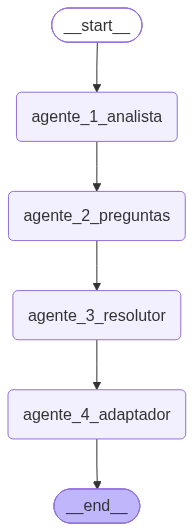

In [7]:
# Celda 8: conecta los cuatro agentes en el flujo lineal del plan.
from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph


graph_builder = StateGraph(QAState)
graph_builder.add_node("agente_1_analista", agente_1_analista)
graph_builder.add_node("agente_2_preguntas", agente_2_preguntas)
graph_builder.add_node("agente_3_resolutor", agente_3_resolutor)
graph_builder.add_node("agente_4_adaptador", agente_4_adaptador)
graph_builder.add_edge(START, "agente_1_analista")
graph_builder.add_edge("agente_1_analista", "agente_2_preguntas")
graph_builder.add_edge("agente_2_preguntas", "agente_3_resolutor")
graph_builder.add_edge("agente_3_resolutor", "agente_4_adaptador")
graph_builder.add_edge("agente_4_adaptador", END)
graph = graph_builder.compile()
print("[Celda 8] Grafo compilado: START -> Agente 1 -> Agente 2 -> Agente 3 -> Agente 4 -> END")

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as error:
    print("Visualizacion no disponible:", error)


### Celda 9: ejecución
Esta celda carga el Markdown convertido, define el perfil de audiencia y ejecuta el grafo completo. También imprime preguntas, respuestas, evidencia y certeza estimada.

In [8]:
# Celda 9: invoca el grafo con la transcripcion convertida y un perfil objetivo.
transcripcion = markdown_path.read_text(encoding="utf-8")
initial_state: QAState = {
    "transcripcion_original": transcripcion,
    "perfil_objetivo": "estudiante universitario",
}

print("[Celda 9] Iniciando flujo con", len(transcripcion), "caracteres")
result = graph.invoke(initial_state)
print("[Celda 9] Flujo terminado")
print("[Celda 9] Preguntas:", len(result["preguntas_generadas"]))
print("[Celda 9] Respuestas:", len(result["respuestas_crudas"]))
print("\nPreguntas y respuestas:\n")
for index, item in enumerate(result["respuestas_crudas"], start=1):
    print(f"{index}. Q: {item['pregunta']}")
    print(f"   A: {item['respuesta'][:500]}...")


[Celda 9] Iniciando flujo con 19010 caracteres
[Agente 1] Evidencia: transcripcion recibida
[Agente 1] Decision: conceptos extraidos con TF-IDF
[Agente 1] Conceptos: bfs, grafo, dfs, figura, malla
[Agente 1] Certeza del metodo: 1.00 (calculo deterministico)
[Agente 2] Evidencia: conceptos del Agente 1
[Agente 2] Decision: respuesta estructurada del LLM
[Agente 2] Preguntas generadas: 5
[Agente 2] Certeza estimada: 0.85
[Agente 3] Pregunta: {1. ¿Cuál es el objetivo principal de la implementación de un Grafo Dirigido Acíclico (DAG) para automatizar la validación de prerrequisitos en una malla curricular universitaria?
[Agente 3] Decision: respuesta del LLM limitada al contexto
[Agente 3] Certeza por evidencia recuperada: 0.90
[Agente 3] Pregunta: {2. ¿Cuál es el tipo de dato abstracto (ADT) utilizado en la implementación y qué paradigma de programación se emplea?
[Agente 3] Decision: respuesta del LLM limitada al contexto
[Agente 3] Certeza por evidencia recuperada: 0.95
[Agente 3] Pregu

### Celda 10: exportación
Esta celda escribe el cuestionario generado en `cuestionario_final.md` y confirma la ubicación y el tamaño del archivo.

In [9]:
# Celda 10: exporta el resultado final y confirma el archivo generado.
output_path = PROJECT_DIR / "outputs" / "cuestionario_final.md"
output_path.write_text(result["cuestionario_final"], encoding="utf-8")
print("[Celda 10] Exportacion completada")
print("Archivo:", output_path)
print("Caracteres escritos:", len(result["cuestionario_final"]))


[Celda 10] Exportacion completada
Archivo: D:\labADA\Presentacion_Jueves\outputs\cuestionario_final.md
Caracteres escritos: 2039


## Guía rápida para ejecutar el sistema

1. Abre PowerShell en `d:\labADA\Presentacion_Jueves`.
2. Activa el entorno existente:
   ```powershell
   .\.venv\Scripts\Activate.ps1
   ```
3. Si necesitas reconstruir el entorno, instala desde `requeriments.txt`:
   ```powershell
   .\.venv\Scripts\python.exe -m pip install -r requeriments.txt
   ```
4. Abre `RAG.ipynb` en VS Code.
5. En **Select Kernel**, selecciona **.venv (Python 3.11.9)**.
6. Ejecuta las celdas en orden. La prueba actual usa `Informe Proyecto Bim 1 EDAII.pdf`.
7. Para activar las respuestas del LLM local, descarga una vez el modelo:
   ```powershell
   ollama pull llama3.1
   ```
   Si el modelo no esta descargado, el notebook usa un fallback basado en evidencia RAG y sigue funcionando.
8. El resultado se guarda como `cuestionario_final.md` y la base de esta prueba como `informe_bim1_edaII.db`.
9. Para salir del entorno:
   ```powershell
   deactivate
   ```

### Archivos demo recomendados

- `.pdf`: informes, manuales, guias, presentaciones o articulos; el notebook los convierte a Markdown con MarkItDown.
- `.md`: documentacion tecnica ya estructurada con titulos y secciones.
- `.txt`: transcripciones, notas de clase o guiones.
- `.docx`: documentos de Word que MarkItDown tambien puede convertir.

Coloca un archivo demo en esta carpeta y cambia `pdf_path` en la celda de ingesta por su nombre. Usa un nombre distinto en `db_path` para cada fuente nueva, evitando mezclar documentos.

Las impresiones muestran trazabilidad observable: evidencia usada, decision tomada, metodo aplicado, fuentes y certeza heuristica. No representan ni exponen el razonamiento privado interno del LLM.